In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines
# from models.gmp import GMP
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

Load data from files

In [3]:
dataset_path = "datasets/Custom_dataset"
# dataset_path = "datasets/DPA_200MHz"
# dataset_path = "datasets/Huawei_dataset"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.get_gained_signals()

print(f"gain: {container.gain}")



gain: 7.750391483306885


In [4]:
def prepare_data_for_als(
    x: torch.Tensor,
    y: torch.Tensor,
    M1: int,
    M2: int,
    P: int,
    N: int,
):
    """_summary_

    Args:
        x (torch.Tensor): _description_
        y (torch.Tensor): _description_
        M1 (int): _description_
        M2 (int): _description_
        P (int): _description_
        N (int): _description_

    Returns:
        y_vec, H, M (tuple[Tensor, Tensor, Tensor]): _description_
    """
    
    x = utils.iq_to_complex(x)
    y = utils.iq_to_complex(y)
    
    T = len(x)
    max_delay = max(M1, M2) - 1
    
    start_idx = max_delay
    assert start_idx + N <= T, f"Too short dataset"
    
    # Выход
    y_vec = y[start_idx:start_idx + N]
    
    # Матрица H
    n_indices = torch.arange(N)[:, None]  # (N, 1)
    i_indices = torch.arange(M1)[None, :]  # (1, M1)
    idx_matrix = start_idx + n_indices - i_indices  # (N, M1)
    
    H = x[idx_matrix]  # (N, M1)
    
    # Тензор M
    j_indices = torch.arange(M2)[None, :]
    idx_matrix_j = start_idx + n_indices - j_indices  # (N, M2)
    abs_vals = torch.abs(x[idx_matrix_j])  # (N, M2)
    
    # Возводим в степени
    M = torch.zeros((N, M2, P), dtype=torch.complex64)
    for p in range(P):
        M[:, :, p] = abs_vals ** p
    
    return y_vec, H, M

In [5]:
def ridge_ls(Phi, y, gamma):
    """
    Solve

        min ||y - Phi w||² + gamma ||w||²

    Phi : (N, K)
    y   : (N,)
    """
    
    if gamma == 0:
        return torch.linalg.lstsq(Phi, y).solution

    K = Phi.shape[1]

    A = torch.matmul(Phi.conj().T, Phi)
    b = torch.matmul(Phi.conj().T, y)

    if gamma > 0:
        A = A + gamma * torch.eye(K, dtype=A.dtype, device=A.device)
        
    w = torch.linalg.solve(A, b)

    return w


def als_identification_of_gmpcp(model, y_vec, H, M, N, L, gamma):
    """
    ALS GMP-CP

    Parameters
    ----------
    model : GMPCP
    x, y  : training signals
    L     : number of ALS iterations
    gamma : ridge parameter
    """
    

    R = model.R
    M1 = model.M1
    M2 = model.M2
    P = model.P
    
    A = model.a.clone()
    B = model.b.clone()
    C = model.c.clone()
    
    for _ in range(L):
        
        # A

        MBC = torch.einsum('njp,jr,pr->nr', M, B, C)
        
        D = H[:, :, None] * MBC[:, None, :]
        D = D.reshape(N, M1 * R)
        
        a = ridge_ls(D, y_vec, gamma)
        A = a.reshape(M1, R)
        
        # B
        
        HA = H @ A

        MC = torch.einsum('njp,pr->njr', M, C)

        E = MC * HA[:, None, :]
        E = E.reshape(N, M2 * R)

        b = ridge_ls(E, y_vec, gamma)
        B = b.reshape(M2, R)
        
        # C
        
        HA = H @ A

        MB = torch.einsum('njp,jr->npr', M, B)

        F = MB * HA[:, None, :]
        F = F.reshape(N, P * R)

        c = ridge_ls(F, y_vec, gamma)
        C = c.reshape(P, R)

    model.set_parameters(A, B, C)

    return model
        

In [6]:

from modules import utils
from models.base_model import BaseModel


class GMPCP(torch.nn.Module, BaseModel):
    def __init__(self, R, M1, M2, P, model_name: str = "", use_even_powers: bool = False):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.R, self.M1, self.M2, self.P = R, M1, M2, P
        
        self.register_buffer('a', 0.1 * torch.randn(M1, R, dtype=torch.complex64))
        self.register_buffer('b', 0.1 * torch.randn(M2, R, dtype=torch.complex64))
        self.register_buffer('c', 0.1 * torch.randn(P, R, dtype=torch.complex64))
        
        self.max_delay = max(self.M1, self.M2) - 1
        self.register_buffer('M1_arange', torch.arange(self.M1))
        self.register_buffer('M2_arange', torch.arange(self.M2))
        
        if use_even_powers:
            self.register_buffer('powers_arange', torch.arange(self.P) * 2)
        else:
            self.register_buffer('powers_arange', torch.arange(self.P))
    
    def _get_filename(self):
        return (f"{self.model_name}_{self.class_name}_"
                f"R({self.R})_M1({self.M1})_"
                f"M2({self.M2})_P({self.P}).pt")
    
    def set_parameters(self, a_new, b_new, c_new):
        """Update parameters"""
        self.a.copy_(a_new)
        self.b.copy_(b_new)
        self.c.copy_(c_new)
    
    def forward(self, x):
        """
        x: (T,) — комплексный входной сигнал
        returns: (T,) — комплексный выходной сигнал
        """
        T = x.shape[0]
        T_cut = T - self.max_delay
        
        y = torch.zeros(T_cut, dtype=torch.complex64, device=x.device)
        
        for n in range(T_cut):
            t = n + self.max_delay

            delays_m1 = x[t - self.M1_arange]
            sum_i = torch.matmul(self.a.T, delays_m1)
            
            delays = x[t - self.M2_arange]
            abs_delays = torch.abs(delays)
            abs_powers = (abs_delays[:, None] ** self.powers_arange[None, :]).to(torch.complex64)
            
            bc = self.b[:, None, :] * self.c[None, :, :]
            sum_jp = torch.einsum('mpr,mp->r', bc, abs_powers,)
            
            y[n] = torch.sum(sum_i * sum_jp)
        
        return y

Algorithm 3 ALS algorithm for the identification of GMP-CP model

In [120]:
R=3
M1=11
M2=10
P=8
N=2048

gamma = 1e-3
L = 30
# torch.manual_seed(42)

model = GMPCP(R=R, M1=M1, M2=M2, P=P, model_name='pa', use_even_powers=False)

N_delay = len(container.train_input) - max(M1, M2) + 1

y_vec, H, M = prepare_data_for_als(x=container.train_input,
                                    y=container.train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )

In [121]:


model = als_identification_of_gmpcp(model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)

# model.save_weights()

In [122]:
x = utils.iq_to_complex(container.val_input_orig)

with torch.no_grad():
    y_pred = model(x)


delay = max(model.M1, model.M2) - 1

y_true = utils.iq_to_complex(container.val_output[delay:])

gmpcp_nmse = metrics.compute_nmse(y_pred, y_true)
print(F"NMSE: {gmpcp_nmse:.2f} dB")

gmpcp_acepr = metrics.compute_acepr(
    measured=y_pred,
    predicted=y_true,
    fs=container.input_signal_fs,
    main_bandwidth=container.bw_main_ch,
    adjacent_bandwidth=container.bw_main_ch,
    channel_offset=container.bw_main_ch,
    nperseg=container.nperseg
)

print(f"ACEPR: {gmpcp_acepr:.2f} dB")

NMSE: -31.33 dB
ACEPR: -38.11 dB


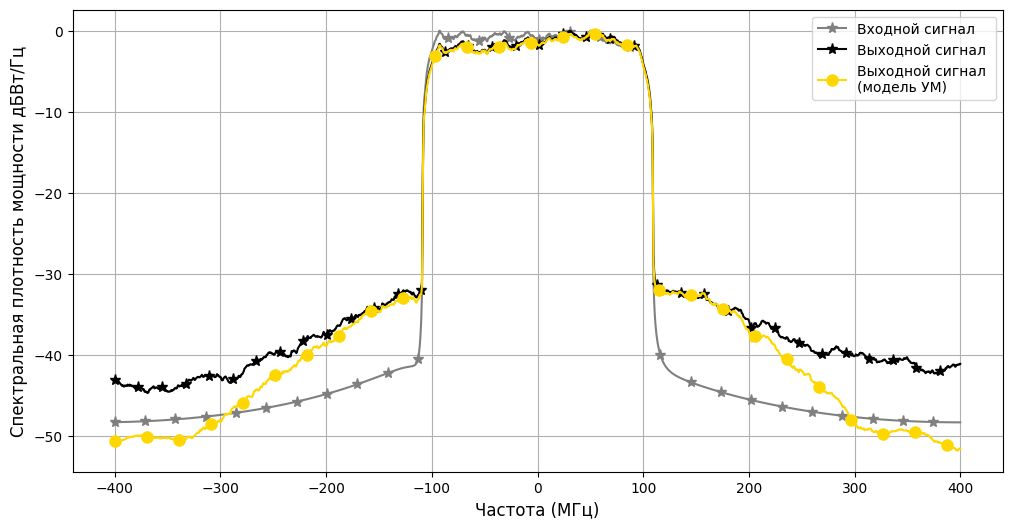

In [123]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_pred, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


In [ ]:

def collect_als_statistics(main_model, M1, M2, P, R_range, num_runs, L, gamma, N, dataset_names_range, use_even_powers: bool = False):
    result_list = []
    
    for dataset_name in dataset_names_range:
        print(f"Dataset: {dataset_name}")
        
        dataset_path = f"datasets/{dataset_name}"
        container = data_loader.DataContainer()
        container.load_data(file_path=dataset_path)
        container.get_gained_signals()
        print(f"gain: {container.gain}")
        y_vec, H, M = prepare_data_for_als(x=container.train_input,
                                    y=container.train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )

        for R in R_range:
            print(f"R: {R}")

            for n in range(num_runs):
                print(f"Run: {n}")
                seed = hash((dataset_name, R, n)) % (2**32)
                torch.manual_seed(seed)
                model = main_model(R=R, M1=M1, M2=M2, P=P, use_even_powers=use_even_powers)
                
                model = als_identification_of_gmpcp(model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)
                
                x = utils.iq_to_complex(container.val_input_orig)

                y_pred = model(x)

                delay = max(model.M1, model.M2) - 1

                y_true = utils.iq_to_complex(container.val_output[delay:])

                gmpcp_nmse = metrics.compute_nmse(y_pred, y_true)
                print(F"NMSE: {gmpcp_nmse:.2f} dB")

                gmpcp_acepr = metrics.compute_acepr(
                    measured=y_pred,
                    predicted=y_true,
                    fs=container.input_signal_fs,
                    main_bandwidth=container.bw_main_ch,
                    adjacent_bandwidth=container.bw_main_ch,
                    channel_offset=container.bw_main_ch,
                    nperseg=container.nperseg
                )

                print(f"ACEPR: {gmpcp_acepr:.2f} dB")
                
                result_list.append({
                    'dataset': dataset_name,
                    'R': R,
                    'run': n,
                    'nmse': float(gmpcp_nmse),
                    'acepr': float(gmpcp_acepr),
                })
    
    return result_list

In [154]:
main_model = GMPCP
M1=10
M2=10
# P=8
P=8
N=4096
gamma = 1e-3
L = 20

R_range = [1, 2, 3, 4, 5, 6]
num_runs = 50
dataset_names_range = ('DPA_200MHz', 'Custom_dataset', 'Huawei_dataset',)


result_list_odd = collect_als_statistics(main_model=main_model,
                       M1=M1,
                       M2=M2, 
                       P=P,
                       R_range=R_range,
                       num_runs=num_runs,
                       L=L,
                       gamma=gamma,
                       N=N,
                       dataset_names_range=dataset_names_range,
                       use_even_powers=False)

Dataset: DPA_200MHz
gain: 2.5208089351654053
R: 1
Run: 0
NMSE: -31.08 dB
ACEPR: -37.79 dB
Run: 1
NMSE: -31.05 dB
ACEPR: -38.08 dB
Run: 2
NMSE: -29.76 dB
ACEPR: -37.76 dB
Run: 3
NMSE: -31.01 dB
ACEPR: -38.00 dB
Run: 4
NMSE: -30.47 dB
ACEPR: -37.86 dB
Run: 5
NMSE: -29.66 dB
ACEPR: -35.68 dB
Run: 6
NMSE: -31.36 dB
ACEPR: -38.09 dB
Run: 7
NMSE: -30.13 dB
ACEPR: -37.92 dB
Run: 8
NMSE: -31.32 dB
ACEPR: -38.01 dB
Run: 9
NMSE: -31.25 dB
ACEPR: -38.10 dB
Run: 10
NMSE: -27.87 dB
ACEPR: -36.35 dB
Run: 11
NMSE: -31.38 dB
ACEPR: -38.13 dB
Run: 12
NMSE: -30.83 dB
ACEPR: -38.00 dB
Run: 13
NMSE: -28.60 dB
ACEPR: -35.25 dB
Run: 14
NMSE: -31.18 dB
ACEPR: -37.99 dB
Run: 15
NMSE: -31.40 dB
ACEPR: -38.10 dB
Run: 16
NMSE: -31.32 dB
ACEPR: -38.09 dB
Run: 17
NMSE: -29.50 dB
ACEPR: -37.02 dB
Run: 18
NMSE: -29.90 dB
ACEPR: -36.37 dB
Run: 19
NMSE: -29.28 dB
ACEPR: -36.79 dB
Run: 20
NMSE: -31.22 dB
ACEPR: -38.11 dB
Run: 21
NMSE: -31.27 dB
ACEPR: -37.93 dB
Run: 22
NMSE: -30.66 dB
ACEPR: -37.53 dB
Run: 23
NMSE: -30

In [128]:
from scipy import stats


def confidence_interval(values, confidence=0.95):
    values = np.asarray(values)

    if len(values) < 2:
        return 0.0

    sem = stats.sem(values)

    h = sem * stats.t.ppf(
        (1 + confidence) / 2,
        len(values) - 1
    )

    return h

def aggregate_measured_data(arrray):
    df = pd.DataFrame(arrray)
    grouped = df.groupby(['dataset', 'R'])
    df_agg = grouped.agg(
        nmse_mean=('nmse', 'mean'),
        nmse_std=('nmse', 'std'),
        nmse_count=('nmse', 'count'),
        nmse_ci=('nmse', confidence_interval),

        acepr_mean=('acepr', 'mean'),
        acepr_std=('acepr', 'std'),
        acepr_count=('acepr', 'count'),
        acepr_ci=('acepr', confidence_interval),
    ).reset_index()
    
    return df_agg

In [155]:
# df_result_odd = pd.DataFrame(result_list_odd)

# grouped = df_result_odd.groupby(['dataset', 'R'])

# df_result_odd_agg = grouped.agg(
#     nmse_mean=('nmse', 'mean'),
#     nmse_std=('nmse', 'std'),
#     nmse_count=('nmse', 'count'),
#     nmse_ci=('nmse', confidence_interval),

#     acepr_mean=('acepr', 'mean'),
#     acepr_std=('acepr', 'std'),
#     acepr_count=('acepr', 'count'),
#     acepr_ci=('acepr', confidence_interval),
# ).reset_index()


df_result_odd_agg = aggregate_measured_data(result_list_odd)
df_result_odd_agg.head()

,dataset,R,nmse_mean,nmse_std,nmse_count,nmse_ci,acepr_mean,acepr_std,acepr_count,acepr_ci
0,Custom_dataset,1,-26.947335,1.412726,50,0.401492,-33.988824,1.758436,50,0.499742
1,Custom_dataset,2,-40.858660,3.087261,50,0.877390,-47.969793,2.445467,50,0.694994
2,Custom_dataset,3,-44.938134,1.589975,50,0.451866,-49.733391,1.865328,50,0.530120
3,Custom_dataset,4,-45.171438,2.383932,50,0.677506,-48.989961,2.118462,50,0.602060
4,Custom_dataset,5,-45.510516,0.509729,50,0.144863,-49.274429,0.511596,50,0.145394


In [130]:
print(df_result_odd_agg)

           dataset   R  nmse_mean  nmse_std  nmse_count   nmse_ci  acepr_mean  \
0   Custom_dataset   1 -27.249092  1.332682          20  0.623715  -34.483211   
1   Custom_dataset   2 -41.049742  2.408473          20  1.127200  -48.091135   
2   Custom_dataset   3 -45.067194  1.606451          20  0.751842  -49.921590   
3   Custom_dataset   4 -44.584754  3.674384          20  1.719665  -48.451319   
4   Custom_dataset   5 -45.417532  0.423245          20  0.198085  -49.201435   
5   Custom_dataset   6 -45.655786  0.735303          20  0.344133  -49.412591   
6   Custom_dataset   7 -45.355554  0.538914          20  0.252219  -49.166401   
7   Custom_dataset   8 -45.300237  0.485685          20  0.227308  -49.154246   
8   Custom_dataset   9 -45.056270  0.515281          20  0.241159  -48.898011   
9   Custom_dataset  10 -45.249026  0.667150          20  0.312236  -49.082969   
10      DPA_200MHz   1 -30.416833  1.036034          20  0.484879  -37.468829   
11      DPA_200MHz   2 -31.1

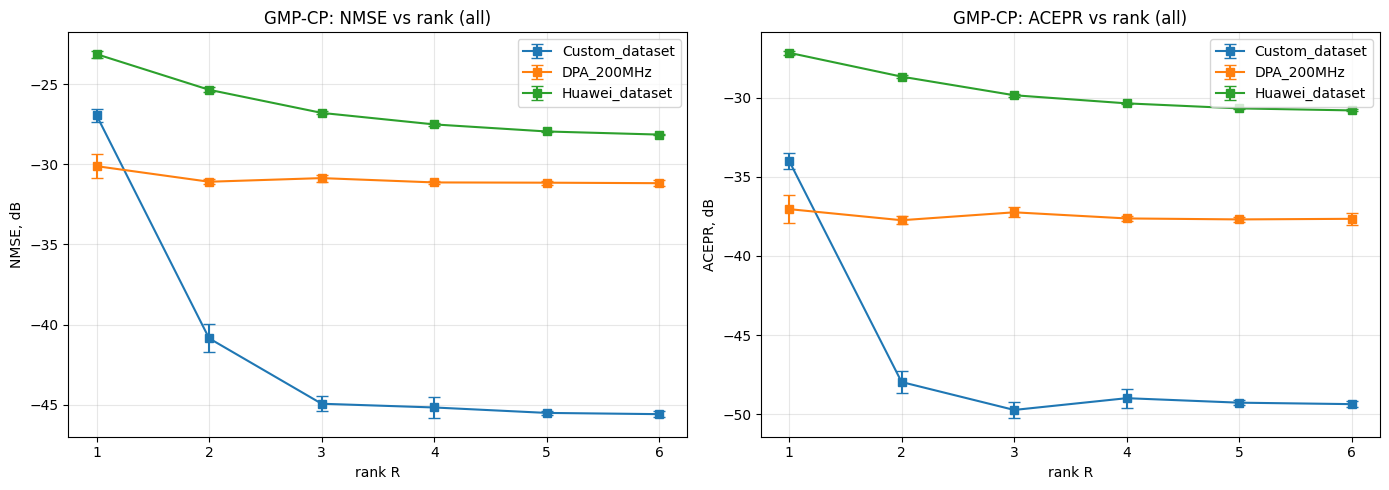

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for dataset_name, group in df_result_odd_agg.groupby('dataset'):

    group = group.sort_values('R')

    axes[0].errorbar(
        group['R'],
        group['nmse_mean'],
        yerr=group['nmse_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )

    axes[1].errorbar(
        group['R'],
        group['acepr_mean'],
        yerr=group['acepr_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )


axes[0].set_xlabel("rank R")
axes[0].set_ylabel("NMSE, dB")
axes[0].set_title("GMP-CP: NMSE vs rank (all)")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(np.arange(1, 7, 1))
axes[0].legend()


axes[1].set_xlabel("rank R")
axes[1].set_ylabel("ACEPR, dB")
axes[1].set_title("GMP-CP: ACEPR vs rank (all)")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(np.arange(1, 7, 1))
axes[1].legend()


plt.tight_layout()
plt.show()

In [141]:

result_list_even = collect_als_statistics(main_model=main_model,
                       M1=M1,
                       M2=M2, 
                       P=P,
                       R_range=R_range,
                       num_runs=num_runs,
                       L=L,
                       gamma=gamma,
                       N=N,
                       dataset_names_range=dataset_names_range,
                       use_even_powers=True)

Dataset: DPA_200MHz
gain: 2.5208089351654053
R: 1
Run: 0
NMSE: -26.97 dB
ACEPR: -34.08 dB
Run: 1
NMSE: -26.86 dB
ACEPR: -35.81 dB
Run: 2
NMSE: -26.66 dB
ACEPR: -34.72 dB
Run: 3
NMSE: -26.97 dB
ACEPR: -34.88 dB
Run: 4
NMSE: -26.80 dB
ACEPR: -35.79 dB
Run: 5
NMSE: -20.55 dB
ACEPR: -26.61 dB
Run: 6
NMSE: -27.11 dB
ACEPR: -35.69 dB
Run: 7
NMSE: -26.64 dB
ACEPR: -34.69 dB
Run: 8
NMSE: -27.00 dB
ACEPR: -35.77 dB
Run: 9
NMSE: -27.03 dB
ACEPR: -35.55 dB
Run: 10
NMSE: -25.25 dB
ACEPR: -35.26 dB
Run: 11
NMSE: -27.11 dB
ACEPR: -35.03 dB
Run: 12
NMSE: -26.88 dB
ACEPR: -34.61 dB
Run: 13
NMSE: -23.05 dB
ACEPR: -29.01 dB
Run: 14
NMSE: -27.41 dB
ACEPR: -35.44 dB
Run: 15
NMSE: -27.08 dB
ACEPR: -35.07 dB
Run: 16
NMSE: -27.12 dB
ACEPR: -34.92 dB
Run: 17
NMSE: -26.87 dB
ACEPR: -33.49 dB
Run: 18
NMSE: -22.53 dB
ACEPR: -29.23 dB
Run: 19
NMSE: -27.36 dB
ACEPR: -33.76 dB
R: 2
Run: 0
NMSE: -27.32 dB
ACEPR: -35.29 dB
Run: 1
NMSE: -27.45 dB
ACEPR: -35.44 dB
Run: 2
NMSE: -27.19 dB
ACEPR: -36.13 dB
Run: 3
NMSE: -2

In [142]:


df_result_even_agg = aggregate_measured_data(result_list_even)
df_result_even_agg.head()

,dataset,R,nmse_mean,nmse_std,nmse_count,nmse_ci,acepr_mean,acepr_std,acepr_count,acepr_ci
0,Custom_dataset,1,-19.249132,2.776218,20,1.299310,-29.734922,0.859195,20,0.402116
1,Custom_dataset,2,-16.950480,0.302521,20,0.141584,-30.271260,0.084633,20,0.039609
2,Custom_dataset,3,-16.631760,0.280482,20,0.131270,-30.376351,0.117746,20,0.055107
3,Custom_dataset,4,-16.455228,1.474238,20,0.689964,-30.476316,0.372957,20,0.174549
4,Custom_dataset,5,-16.036996,0.123815,20,0.057947,-30.575495,0.049094,20,0.022977


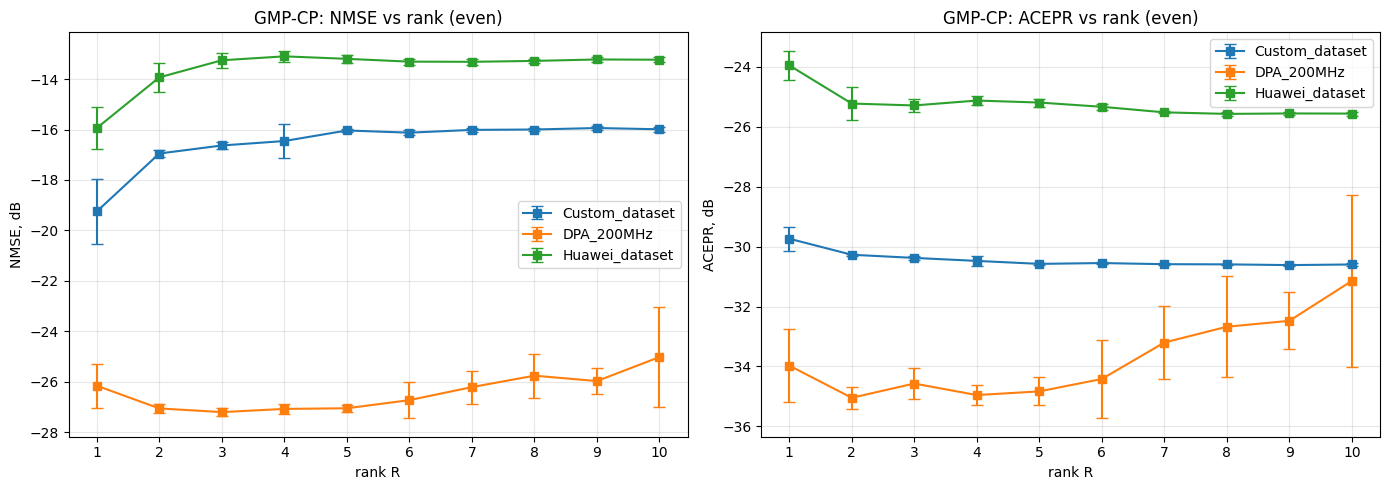

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for dataset_name, group in df_result_even_agg.groupby('dataset'):

    group = group.sort_values('R')

    axes[0].errorbar(
        group['R'],
        group['nmse_mean'],
        yerr=group['nmse_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )

    axes[1].errorbar(
        group['R'],
        group['acepr_mean'],
        yerr=group['acepr_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )


axes[0].set_xlabel("rank R")
axes[0].set_ylabel("NMSE, dB")
axes[0].set_title("GMP-CP: NMSE vs rank (even)")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(np.arange(1, 11, 1))
axes[0].legend()


axes[1].set_xlabel("rank R")
axes[1].set_ylabel("ACEPR, dB")
axes[1].set_title("GMP-CP: ACEPR vs rank (even)")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(np.arange(1, 11, 1))
axes[1].legend()


plt.tight_layout()
plt.show()

Basic GMP

In [16]:
class GMPBase(torch.nn.Module, BaseModel):

    def __init__(self, M1, M2, P, model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)

        self.M1=M1
        self.M2=M2
        self.P=P
        
        self.register_buffer("S", 0.001*torch.randn(M1, M2, P, dtype=torch.complex64))
    
    def set_parameters(self, S_new):
        """Update parameters"""
        self.S.copy_(S_new)

    def forward(self, x):

        T = len(x)
        delay = max(self.M1, self.M2) - 1

        y = torch.zeros(T-delay, dtype=torch.complex64)
        
        abs_x = torch.abs(x)

        for n in range(T-delay):

            t = n + delay

            result = 0j
            for i in range(self.M1):
                for j in range(self.M2):
                    for p in range(self.P):
                        result += (self.S[i,j,p] * x[t-i] * abs_x[t-j]**p)

            y[n] = result

        return y

In [8]:
def prepare_data_for_gmp(x, y, M1, M2, P, N):
    x = utils.iq_to_complex(x)
    y = utils.iq_to_complex(y)
    
    max_delay = max(M1, M2)-1
    start = max_delay
    
    y_vec = y[start:start+N]

    # индексы задержек
    n_idx = torch.arange(N)[:,None]
    i_idx = torch.arange(M1)[None,:]
    j_idx = torch.arange(M2)[None,:]

    # x(t-i)
    x_i = x[start+n_idx-i_idx]

    # x(t-j)
    x_j = x[start+n_idx-j_idx]

    abs_xj = torch.abs(x_j)

    Phi = []

    for i in range(M1):
        for j in range(M2):
            for p in range(P):
                feature = (x_i[:,i] * abs_xj[:,j]**p)
                Phi.append(feature)

    Phi = torch.stack(Phi, dim=1)

    return y_vec, Phi

def identify_gmp(
    model,
    x,
    y,
    M1,
    M2,
    P,
    gamma=0
):

    # LS
    s = ridge_ls(x, y, gamma)

    # vec^-1(S)
    S = s.reshape(M1, M2, P)

    model.set_parameters(S)

    return model

In [17]:
M1=11
M2=10
P=8
N=2048

gamma = 1e-3
L = 30

y, x = prepare_data_for_gmp(x=container.train_input,
                                  y=container.train_output, 
                                  M1=M1, 
                                  M2=M2, 
                                  P=P, 
                                  N=N)


model_gmp = GMPBase(M1=M1, M2=M2, P=P)

model_gmp = identify_gmp(
    model_gmp,
    x,
    y,
    M1,
    M2,
    P,
    gamma=0
)



In [18]:
x_val = utils.iq_to_complex(container.val_input_orig)

with torch.no_grad():
    y_pred = model_gmp(x_val)


delay = max(model.M1, model.M2) - 1

y_true = utils.iq_to_complex(container.val_output[delay:])

gmp_nmse = metrics.compute_nmse(y_pred, y_true)
print(F"NMSE: {gmp_nmse:.2f} dB")

gmp_acepr = metrics.compute_acepr(
    measured=y_pred,
    predicted=y_true,
    fs=container.input_signal_fs,
    main_bandwidth=container.bw_main_ch,
    adjacent_bandwidth=container.bw_main_ch,
    channel_offset=container.bw_main_ch,
    nperseg=container.nperseg
)

print(f"ACEPR: {gmp_acepr:.2f} dB")


window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_pred, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


KeyboardInterrupt: 